In [6]:
import pandas as pd
import matplotlib.pyplot as plt

spx = pd.read_csv("../data/spx.csv", index_col=0, parse_dates=True)
stable = pd.read_csv("../data/stable.csv", index_col=0, parse_dates=True)
tech = pd.read_csv("../data/tech.csv", index_col=0, parse_dates=True)
btc = pd.read_csv("../data/btc.csv", index_col=0, parse_dates=True)

for name, df in [("SPX", spx), ("Stable", stable), ("Tech", tech), ("BTC", btc)]:
    print(f"{name}: {df.index.min()} to {df.index.max()}, {len(df)} rows")
    

SPX: 2017-01-03 00:00:00 to 2024-12-31 00:00:00, 2012 rows
Stable: 2017-01-03 00:00:00 to 2024-12-31 00:00:00, 2012 rows
Tech: 2017-01-03 00:00:00 to 2024-12-31 00:00:00, 2012 rows
BTC: 2017-01-01 00:00:00 to 2024-12-31 00:00:00, 2922 rows


In [7]:
for name, df in [("SPX", spx), ("Stable", stable), ("Tech", tech), ("BTC", btc)]:
    print(f"{name} missing values:\n{df.isna().sum()}\n")
    

SPX missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Stable missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Tech missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

BTC missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64



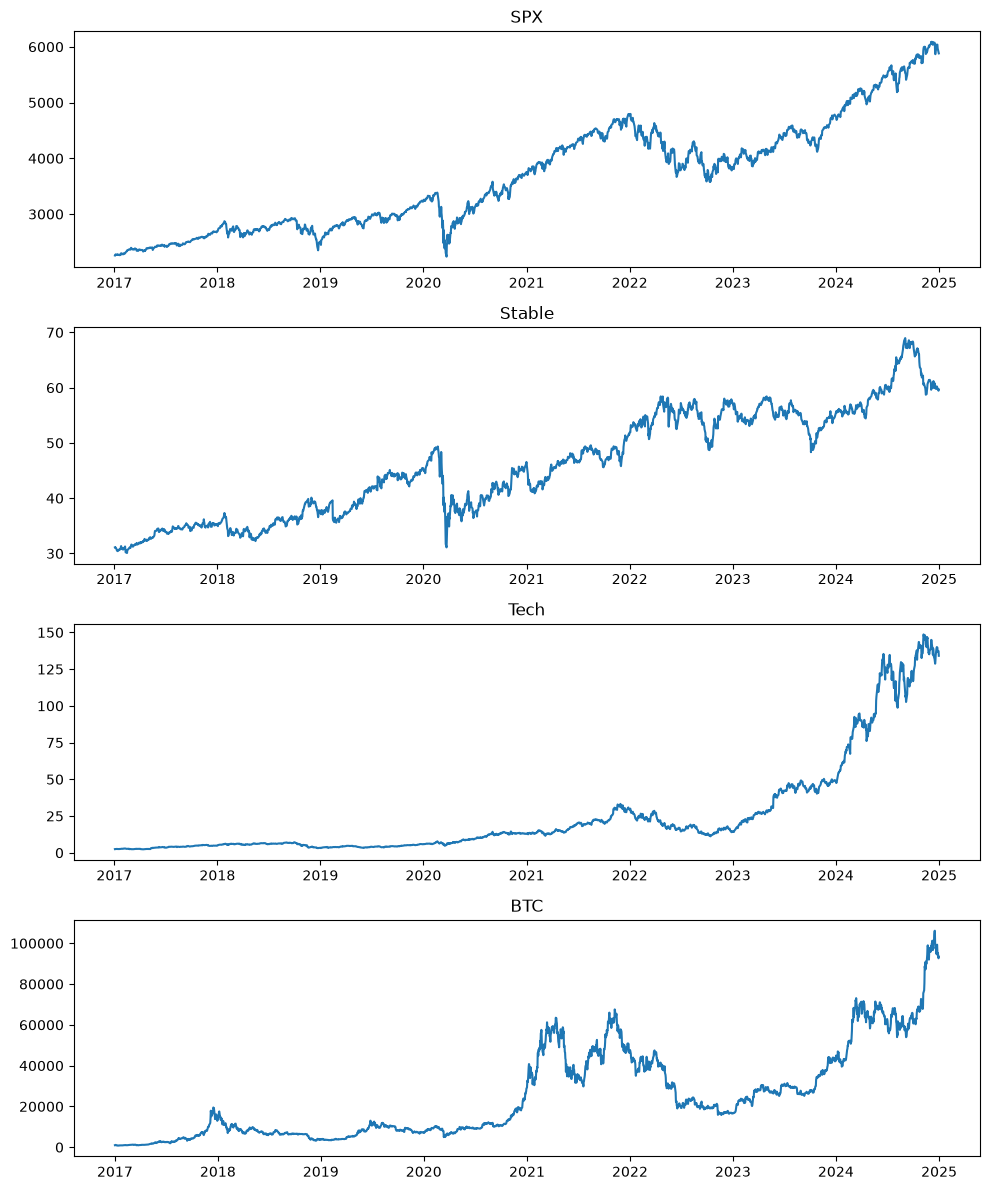

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12))
for ax, (name, df) in zip(axes, [("SPX", spx), ("Stable", stable), ("Tech", tech), ("BTC", btc)]):
    ax.plot(df.index, df["Close"])
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [9]:
print("SPX trading days per week (sample):")
print(spx.index.dayofweek.value_counts().sort_index())

print("\nBTC trading days per week (sample):")
print(btc.index.dayofweek.value_counts().sort_index())


SPX trading days per week (sample):
Date
0    375
1    414
2    411
3    407
4    405
Name: count, dtype: int64

BTC trading days per week (sample):
Date
0    418
1    418
2    417
3    417
4    417
5    417
6    418
Name: count, dtype: int64


In [10]:
merged = spx[["Close"]].rename(columns={"Close": "spx"})
merged = merged.join(stable[["Close"]].rename(columns={"Close": "stable"}), how="inner")
merged = merged.join(tech[["Close"]].rename(columns={"Close": "tech"}), how="inner")
merged = merged.join(btc[["Close"]].rename(columns={"Close": "btc"}), how="inner")

print(f"Merged dataset: {len(merged)} rows, {merged.index.min()} to {merged.index.max()}")
merged.head()

Merged dataset: 2012 rows, 2017-01-03 00:00:00 to 2024-12-31 00:00:00


,spx,stable,tech,btc
Date,,,,
2017-01-03,2257.830078,31.101967,2.509147,1043.839966
2017-01-04,2270.750000,30.990360,2.567688,1154.729980
2017-01-05,2269.000000,31.064770,2.502505,1013.380005
2017-01-06,2276.979980,31.057333,2.535957,902.200989
2017-01-09,2268.899902,30.744812,2.638773,902.828003


In [11]:
merged.to_csv("../data/merged_prices.csv")